# Review Text Similarity Check

This notebook samples Amazon **Beauty and Personal Care** review text and measures cosine
similarity of review pairs grouped by rating agreement.

In [1]:
# ! pip install pandas numpy torch sentence-transformers matplotlib

In [2]:
import json
import random
from collections import defaultdict
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer

# --- Config ---
JSONL_PATH = '../data/Beauty_and_Personal_Care.jsonl'
MODEL_NAME = 'BAAI/bge-base-en-v1.5'
SEED = 67

MAX_LINES_SCAN = 2_000_000   # how many review lines to stream (raise to scan more of the 4.9 GB file)
MIN_PER_POLARITY = 6         # an item must have >= this many 5-star AND >= this many 1-star reviews
TOP_ITEMS = 12               # number of qualifying items to keep for the aggregate analysis
CAP_PER_ITEM = 80            # max reviews kept per item
CHAR_LIMIT = 800             # truncate each review body before encoding

random.seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print('Using device:', DEVICE)

/Users/yudhistiraonggowarsito/Documents/SMU/Courses/CS608 - Recommender Systems/grp_project/yc-code/amazon-item-recommender/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## Pass 1 — find items with both happy and unhappy reviews

The file is ~4.9 GB, so we stream it. The first pass reads only `rating` and `parent_asin`
to locate items that have several strongly-positive (>= 4) and strongly-negative (<= 2) reviews.

In [3]:
# Pass 1: stream once and tally, per item, how many positive (>=4) and
# negative (<=2) reviews it has. Cheap — only two fields parsed per line.
pos_neg = defaultdict(lambda: [0, 0])

with open(JSONL_PATH) as f:
    for i, line in enumerate(f):
        if i >= MAX_LINES_SCAN:
            break
        try:
            d = json.loads(line)
        except json.JSONDecodeError:
            continue
        rating = d.get('rating')
        asin = d.get('parent_asin') or d.get('asin')
        if asin is None or rating is None:
            continue
        if rating >= 4:
            pos_neg[asin][0] += 1
        elif rating <= 2:
            pos_neg[asin][1] += 1

candidates = [
    (asin, p, n) for asin, (p, n) in pos_neg.items()
    if p >= MIN_PER_POLARITY and n >= MIN_PER_POLARITY
]
candidates.sort(key=lambda x: min(x[1], x[2]), reverse=True)
target_items = {asin for asin, _, _ in candidates[:TOP_ITEMS]}

print('Scanned lines:', min(i + 1, MAX_LINES_SCAN))
print('Items with both polarities:', len(candidates))
print('Keeping', len(target_items), 'items for analysis')

Scanned lines: 2000000
Items with both polarities: 9234
Keeping 12 items for analysis


## Pass 2 — collect the review texts for those items

In [4]:
# Pass 2: stream again and collect (rating, title, text) for just the
# selected items, capped per item.
reviews = {asin: [] for asin in target_items}

with open(JSONL_PATH) as f:
    for i, line in enumerate(f):
        if i >= MAX_LINES_SCAN:
            break
        try:
            d = json.loads(line)
        except json.JSONDecodeError:
            continue
        asin = d.get('parent_asin') or d.get('asin')
        if asin not in reviews:
            continue
        if len(reviews[asin]) >= CAP_PER_ITEM:
            continue
        rating = d.get('rating')
        if rating is None:
            continue
        title = (d.get('title') or '').strip()
        text = (d.get('text') or '').strip()
        body = (title + '. ' + text).strip()[:CHAR_LIMIT]
        if body:
            reviews[asin].append((float(rating), title, body))

# Drop items that ended up too small to form meaningful pairs.
for asin in list(reviews):
    if len(reviews[asin]) < 2 * MIN_PER_POLARITY:
        del reviews[asin]

print('Items retained:', len(reviews))
print('Total reviews collected:', sum(len(v) for v in reviews.values()))

Items retained: 12
Total reviews collected: 960


## Encode review text

Every collected review is encoded with BGE. With `normalize_embeddings=True`, cosine
similarity is just the dot product.

In [5]:
model = SentenceTransformer(MODEL_NAME, device=DEVICE)

emb = {}
for asin, revs in reviews.items():
    bodies = [r[2] for r in revs]
    vecs = model.encode(bodies, batch_size=128, normalize_embeddings=True, show_progress_bar=False)
    emb[asin] = np.asarray(vecs, dtype=np.float32)

dim = next(iter(emb.values())).shape[1]
print('Encoded reviews for', len(emb), 'items; embedding dim =', dim)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 34276.48it/s]


Encoded reviews for 12 items; embedding dim = 768


## Pair examples

In [8]:
# Within a single item, find an OPPOSITE-rating (1 vs 5) pair whose cosine
# similarity exceeds some SAME-rating pair, and print the offending titles.
def show_counterexample(asin):
    revs = reviews[asin]
    vecs = emb[asin]
    ratings = np.array([r[0] for r in revs])
    S = vecs @ vecs.T   # cosine, vectors are L2-normalized
    n = len(revs)
    opp, same = [], []
    for a in range(n):
        for b in range(a + 1, n):
            both_5 = ratings[a] == 5 and ratings[b] == 5
            both_1 = ratings[a] == 1 and ratings[b] == 1
            if both_5 or both_1:
                same.append((S[a, b], a, b))
            elif {ratings[a], ratings[b]} == {1.0, 5.0}:
                opp.append((S[a, b], a, b))
    if not opp or not same:
        return False
    opp.sort(reverse=True)
    same.sort()
    best_opp = opp[0]
    worst_same = same[0]
    if best_opp[0] <= worst_same[0]:
        return False
    print('ITEM', asin)
    print()
    print('Most-similar OPPOSITE-rating (1 vs 5) pair: cosine =', round(float(best_opp[0]), 4))
    _, a, b = best_opp
    print('  [rating', int(ratings[a]), ']', revs[a][1])
    print('  [rating', int(ratings[b]), ']', revs[b][1])
    print()
    print('Least-similar SAME-rating pair: cosine =', round(float(worst_same[0]), 4))
    _, a, b = worst_same
    print('  [rating', int(ratings[a]), ']', revs[a][1])
    print('  [rating', int(ratings[b]), ']', revs[b][1])
    print()
    print('=> Opposite-rating reviews are MORE similar than same-rating reviews for this item.')
    return True

found = False
break_counter = 10
for asin in reviews:
    if show_counterexample(asin):
        found = True
        break_counter -= 1
    
    if break_counter <= 0:
        break
if not found:
    print('No single-item counterexample in this sample — see the aggregate stats below.')

ITEM B0BG8W4FV8

Most-similar OPPOSITE-rating (1 vs 5) pair: cosine = 0.7331
  [rating 5 ] Great set, worth the money.
  [rating 1 ] Disappointed! Very cheap quality

Least-similar SAME-rating pair: cosine = 0.266
  [rating 5 ] great polishes! so many colors!
  [rating 5 ] Ok

=> Opposite-rating reviews are MORE similar than same-rating reviews for this item.
ITEM B0BSPDF7T4

Most-similar OPPOSITE-rating (1 vs 5) pair: cosine = 0.7326
  [rating 1 ] Ugh!
  [rating 5 ] Loved it

Least-similar SAME-rating pair: cosine = 0.3408
  [rating 5 ] Red lip tint
  [rating 5 ] Love it

=> Opposite-rating reviews are MORE similar than same-rating reviews for this item.
ITEM B0B867N2Y6

Most-similar OPPOSITE-rating (1 vs 5) pair: cosine = 0.7374
  [rating 1 ] TINY! DO NOT PURCHASE
  [rating 5 ] Just o.k.

Least-similar SAME-rating pair: cosine = 0.3272
  [rating 5 ] Solid product
  [rating 5 ] Great

=> Opposite-rating reviews are MORE similar than same-rating reviews for this item.
ITEM B0BVGHXZJ1



## Aggregate evidence across items

Compare cosine similarity by rating gap using the executed tables and plots below.

Total within-item pairs: 37920

Cosine similarity by rating gap:
              mean  median  count
gap_bucket                       
0           0.6166  0.6214  15313
1           0.5967  0.6018   7367
2           0.5710  0.5749   5515
3           0.5478  0.5461   4168
4           0.5243  0.5243   5557

Median cosine, same-rating pairs (gap 0): 0.6214
Median cosine, opposite pairs (gap 4):    0.5243
Share of opposite pairs above the same-rating median: 0.174
Pearson corr(rating gap, cosine): -0.3251 (near 0 => text ignores preference)


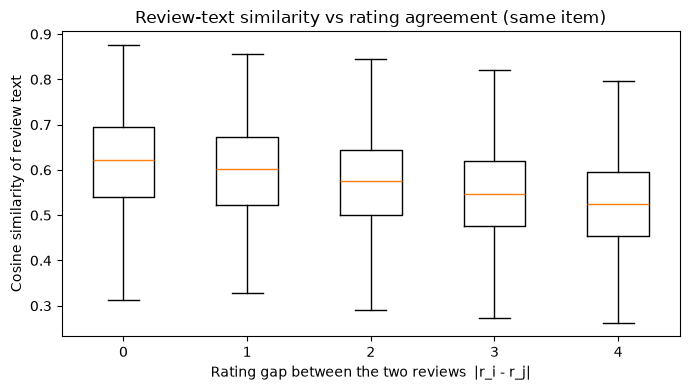

In [7]:
import matplotlib.pyplot as plt

# For every within-item review pair, record the rating gap and the cosine similarity.
records = []
for asin, revs in reviews.items():
    vecs = emb[asin]
    ratings = np.array([r[0] for r in revs])
    S = vecs @ vecs.T
    n = len(revs)
    for a in range(n):
        for b in range(a + 1, n):
            records.append((abs(ratings[a] - ratings[b]), float(S[a, b])))

pairs = pd.DataFrame(records, columns=['rating_gap', 'cosine'])
pairs['gap_bucket'] = pairs['rating_gap'].round().astype(int)

print('Total within-item pairs:', len(pairs))
print()
print('Cosine similarity by rating gap:')
print(pairs.groupby('gap_bucket')['cosine'].agg(['mean', 'median', 'count']).round(4))

same = pairs[pairs['gap_bucket'] == 0]['cosine']
opp = pairs[pairs['gap_bucket'] == 4]['cosine']   # 1-star vs 5-star
frac = float((opp > same.median()).mean())
print()
print('Median cosine, same-rating pairs (gap 0):', round(float(same.median()), 4))
print('Median cosine, opposite pairs (gap 4):   ', round(float(opp.median()), 4))
print('Share of opposite pairs above the same-rating median:', round(frac, 3))

corr = float(pairs['rating_gap'].corr(pairs['cosine']))
print('Pearson corr(rating gap, cosine):', round(corr, 4), '(near 0 => text ignores preference)')

order = sorted(pairs['gap_bucket'].unique())
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([pairs[pairs['gap_bucket'] == g]['cosine'] for g in order], showfliers=False)
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order)
ax.set_xlabel('Rating gap between the two reviews  |r_i - r_j|')
ax.set_ylabel('Cosine similarity of review text')
ax.set_title('Review-text similarity vs rating agreement (same item)')
plt.tight_layout()
plt.show()

## Notes

Use the executed tables and plots above for interpretation.